In [101]:
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.layers import Embedding, Input, Dense, Flatten, Concatenate, Dropout
from keras.models import Model
from keras.optimizers import AdamW
from keras.losses import MeanSquaredError
from keras.callbacks import ReduceLROnPlateau

In [64]:
df = pd.read_csv("/mnt/e/Deep Learning/data/bike_sharing_demand/train.csv")
df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [66]:
df['day_of_week'] = pd.to_datetime(df['datetime']).dt.dayofweek

In [67]:
features = ['day_of_week', "temp", "humidity", "windspeed", 'count']
df = df[features]

In [68]:
x = df.drop("count", axis=1)
y = df['count']

In [69]:
y

0         16
1         40
2         32
3         13
4          1
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 10886, dtype: int64

In [70]:
x

,day_of_week,temp,humidity,windspeed
0,5,9.84,81,0.0000
1,5,9.02,80,0.0000
2,5,9.02,80,0.0000
3,5,9.84,75,0.0000
4,5,9.84,75,0.0000
...,...,...,...,...
10881,2,15.58,50,26.0027
10882,2,14.76,57,15.0013
10883,2,13.94,61,15.0013
10884,2,13.94,61,6.0032


In [71]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, train_size=0.2)

In [72]:
st_temp = StandardScaler()
st_humidity = StandardScaler()
st_windspeed = StandardScaler()

x_train[['temp']] = st_temp.fit_transform(x_train[['temp']])
x_train[['humidity']] = st_humidity.fit_transform(x_train[['humidity']])
x_train[['windspeed']] = st_windspeed.fit_transform(x_train[['windspeed']])

x_test[['temp']] = st_temp.transform(x_test[['temp']])
x_test[['humidity']] = st_humidity.transform(x_test[['humidity']])
x_test[['windspeed']] = st_windspeed.transform(x_test[['windspeed']])

In [73]:
x_train.head()

,day_of_week,temp,humidity,windspeed
3983,5,-0.183854,0.535987,-0.230919
10415,0,-0.715536,0.223481,0.507817
780,1,-1.353555,-0.922372,-1.586231
8970,3,0.666837,0.588071,0.507817
5607,6,-0.821873,-0.818204,0.261847


In [74]:
max_y = int(y_train.max())
y_train = y_train / max_y
y_test = y_test / max_y

____

In [92]:
num_days = 7
embedd_dim = 3
num_numerical = x_train.shape[1] - 1    # without categorical

input_day_of_week = Input(shape=(1, ), name='input_day_of_week')
Embedding_day_of_week = Embedding(input_dim=num_days, output_dim=embedd_dim)(input_day_of_week)
flat_embedd = Flatten()(Embedding_day_of_week)

input_numerical = Input(shape=(num_numerical, ), name='input_numerical')

concatenated = Concatenate()([flat_embedd, input_numerical])

x = Dense(64, activation='relu')(concatenated)
x = Dropout(0.3)(x)

output = Dense(1, activation='linear')(x)

In [93]:
model = Model([input_day_of_week, input_numerical], output)

In [94]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 3)      │         21 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 3)         │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerical     │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 6)         │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ input_numerical[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        448 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 534 (2.09 KB)

 Trainable params: 534 (2.09 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
x_train_numerical = x_train.drop(['day_of_week'], axis=1)
x_test_numerical = x_test.drop(['day_of_week'], axis=1)

In [96]:
train_ds = tf.data.Dataset.from_tensor_slices((
    {
        "input_day_of_week": x_train['day_of_week'],
        "input_numerical": x_train_numerical    
    },
    y_train
))

val_ds = tf.data.Dataset.from_tensor_slices((
    {
        "input_day_of_week": x_test['day_of_week'],
        "input_numerical": x_test_numerical
    },
    y_test
))

In [97]:
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE).batch(128)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE).batch(128)

In [98]:
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25)

In [99]:
from keras.optimizers import RMSprop

model.compile(optimizer=RMSprop(learning_rate=0.001), 
              loss=MeanSquaredError,
              metrics=['mae'])

In [100]:
history = model.fit(train_ds, validation_data=val_ds, epochs=300, callbacks=[lr_callback])

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1379 - mae: 0.2896 - val_loss: 0.0616 - val_mae: 0.1891 - learning_rate: 0.0010
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0761 - mae: 0.2116 - val_loss: 0.0421 - val_mae: 0.1553 - learning_rate: 0.0010
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0630 - mae: 0.1934 - val_loss: 0.0372 - val_mae: 0.1447 - learning_rate: 0.0010
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0573 - mae: 0.1860 - val_loss: 0.0349 - val_mae: 0.1394 - learning_rate: 0.0010
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0520 - mae: 0.1733 - val_loss: 0.0334 - val_mae: 0.1378 - learning_rate: 0.0010
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0479 - mae: 0.1717 - val_loss: 0.0329 - val_mae: 0.1378 - learning_rate: 0.0010
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0466 - mae: 0.1664 - val_loss: 0.0324 - val_mae: 0.1362 - learning_rate: 0.0010
Epoch 8/30

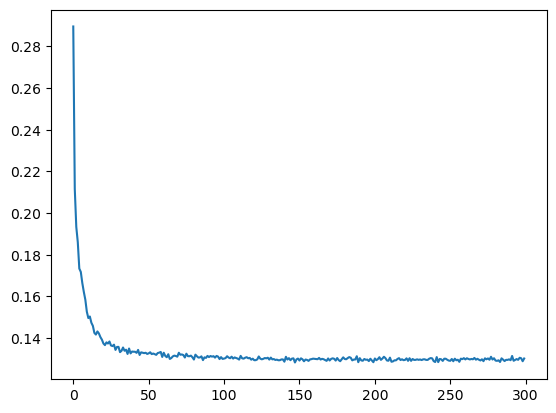

In [104]:
plt.plot(history.history['mae'])


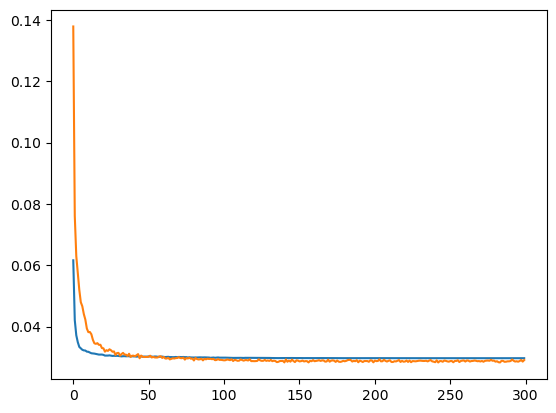

In [ ]:
plt.plot(history.history["val_loss"])
plt.plot(history.history["loss"])


____

In [109]:
for l in model.layers:
    print(l)

<InputLayer name=input_day_of_week, built=True>
<Embedding name=embedding_4, built=True>
<Flatten name=flatten_4, built=True>
<InputLayer name=input_numerical, built=True>
<Concatenate name=concatenate_3, built=True>
<Dense name=dense_5, built=True>
<Dropout name=dropout_2, built=True>
<Dense name=dense_6, built=True>


In [112]:
embedd_layer = model.layers[1]
embedding_weights = embedd_layer.get_weights()[0]
print(f"Shape of embedding weights is: {embedding_weights.shape}")

Shape of embedding weights is: (7, 3)


In [113]:
from sklearn.decomposition import PCA

In [114]:
pca = PCA(n_components=2)

pca_embedding = pca.fit_transform(embedding_weights) 

In [115]:
pca_embedding

array([[-0.18155032, -0.17003368],
       [-0.0728718 , -0.05148076],
       [-0.21225108,  0.12597856],
       [ 0.08811214,  0.09844646],
       [-0.03527101,  0.05995902],
       [ 0.18063289, -0.00417579],
       [ 0.23319918, -0.05869371]], dtype=float32)

In [116]:
days_of_week = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

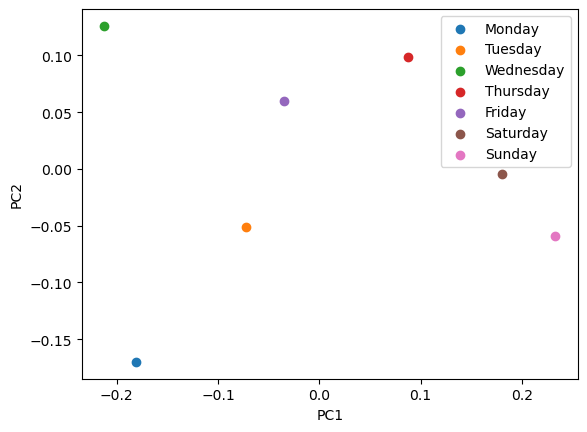

In [120]:
for i, day in enumerate(days_of_week):
    plt.scatter(pca_embedding[i][0], pca_embedding[i][1], label=day)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()